Dengan menggunakan data passanger.csv, lakukanlah data preparation pada breakoutroom kali ini.

In [1]:
from google.colab import drive
drive.mount('/content/gdrive')

Mounted at /content/gdrive


In [2]:
import os
import pandas as pd

In [3]:
# Inisiasi directory tempat data akan dibaca dan disimpan
path = '/content/gdrive/My Drive/PKKM KA/Day 1/Data Preparation/Data/'#silahkan masukkan path sesuai dengan letak data di drive masing-masing

In [4]:
# Cek isi direktori
os.listdir(path)

['iris.csv',
 'passenger.csv',
 'ride_sharing_new.csv',
 'sales.csv',
 'titanic.csv',
 'titanic2.csv',
 'sales with standardized and normalized data.csv']

In [5]:
# Load the data
df = pd.read_csv(path + 'passenger.csv')

In [6]:
df.head()

,Unnamed: 0,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


# Case 1

Berikan informasi-informasi terkait data passenger.

In [7]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 892 entries, 0 to 891
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Unnamed: 0   892 non-null    int64  
 1   PassengerId  892 non-null    int64  
 2   Survived     892 non-null    int64  
 3   Pclass       892 non-null    int64  
 4   Name         892 non-null    object 
 5   Sex          892 non-null    object 
 6   Age          715 non-null    float64
 7   SibSp        892 non-null    int64  
 8   Parch        892 non-null    int64  
 9   Ticket       892 non-null    object 
 10  Fare         892 non-null    float64
 11  Cabin        205 non-null    object 
 12  Embarked     890 non-null    object 
dtypes: float64(2), int64(6), object(5)
memory usage: 90.7+ KB
None


In [11]:
print(df.dtypes)

Unnamed: 0       int64
PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object


In [12]:
print(df.shape)

(892, 13)


Bagaimana Summary Statistics dari data tersebut ?



In [10]:
print(df.describe())

       Unnamed: 0  PassengerId    Survived      Pclass         Age  \
count  892.000000   892.000000  892.000000  892.000000  715.000000   
mean   445.500000   446.495516    0.384529    2.307175   29.684154   
std    257.642517   257.634789    0.486757    0.836750   14.521835   
min      0.000000     1.000000    0.000000    1.000000    0.420000   
25%    222.750000   223.750000    0.000000    2.000000   20.000000   
50%    445.500000   446.500000    0.000000    3.000000   28.000000   
75%    668.250000   669.250000    1.000000    3.000000   38.000000   
max    891.000000   891.000000    1.000000    3.000000   80.000000   

            SibSp       Parch        Fare  
count  892.000000  892.000000  892.000000  
mean     0.522422    0.381166   32.201737  
std      1.102264    0.805706   49.665589  
min      0.000000    0.000000    0.000000  
25%      0.000000    0.000000    7.917700  
50%      0.000000    0.000000   14.454200  
75%      1.000000    0.000000   31.000000  
max      8.000000

# Case 2

Apakah terdapat Missing Values ?

In [15]:
miss = df.isnull().sum()
miss

,0
Unnamed: 0,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0


Apabila terdapat missing values, lakukanlah data cleaning.

In [16]:
rasio = miss.div(len(df))
rasio

,0
Unnamed: 0,0.000000
PassengerId,0.000000
Survived,0.000000
Pclass,0.000000
Name,0.000000
Sex,0.000000
Age,0.198430
SibSp,0.000000
Parch,0.000000
Ticket,0.000000


In [17]:
df = df.drop(['Cabin'], axis=1) #drop karena lebih dari 70%

In [18]:
df.head()

,Unnamed: 0,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S
1,1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C
2,2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S
3,3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S
4,4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S


In [19]:
df['Age'].describe()

,Age
count,715.000000
mean,29.684154
std,14.521835
min,0.420000
25%,20.000000
50%,28.000000
75%,38.000000
max,80.000000


In [20]:
df['Age'].fillna(int(df['Age'].mean()), inplace=True)

<ipython-input-20-4a21dccbdac8>:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(int(df['Age'].mean()), inplace=True)


In [21]:
pd.isnull(df).sum()

,0
Unnamed: 0,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0


In [22]:
df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)

<ipython-input-22-808ebb813aa0>:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)


In [23]:
pd.isnull(df).sum()

,0
Unnamed: 0,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0


# Case 3

Apakah terdapat data duplicate?

In [24]:
df.duplicated().sum()

0

Apabila terdapat duplicate, hapuslah data duplikasinya.

# Case 4

Data pada kolom Age memiliki tipe data float, ubahlah tipe data Age menjadi integer.

In [25]:
df['Age_int'] = df['Age'].astype(int)

In [26]:
df["Age_int"].dtypes

dtype('int64')

# Case 5

Hitunglah jumlah penumpang berdasar jenis kelaminnya!

In [30]:
jenis_kelamin = df[['PassengerId','Sex']].groupby('Sex').count()
jenis_kelamin

,PassengerId
Sex,
female,315
male,577


Kelompokkan jumlah penumpang berdasar kolom embarked

In [31]:
embarked = df[['PassengerId','Embarked']].groupby('Embarked').count()
embarked

,PassengerId
Embarked,
C,168
Q,77
S,647


Lakukan penggabungan pengelompokan berdasar kedua pengelompokan sebelumnya yaitu berdasar embarked dan jenis kelamin.

In [32]:
df_group = df.groupby(['Embarked', 'Sex'])['PassengerId'].count().unstack()
df_group

Sex,female,male
Embarked,,
C,73,95
Q,36,41
S,206,441


# Case 6

Berapakah rata-rata usia penumpang?

In [33]:
df['Age'].mean()

29.548396860986546

Berapa rata-rata tarif penumpang?

In [34]:
df['Fare'].mean()

32.201736883408074

Berapa rata-rata tarif setiap kelasnya?

In [35]:
df[['Pclass','Fare']].groupby('Pclass').mean()

,Fare
Pclass,
1,83.905127
2,20.662183
3,13.675550


Buatlah chart, dengan melihat berapa banyak yang selamat pada jenis kelamin laki-laki dan perempuan

In [37]:
df_group = df.groupby(['Sex'])['Survived'].sum()
df_group

,Survived
Sex,
female,234
male,109


<function matplotlib.pyplot.show(close=None, block=None)>

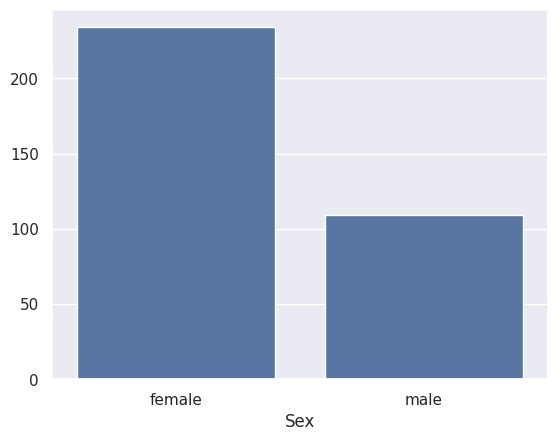

In [39]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set(style="darkgrid")
sns.barplot(x=df_group.index, y=df_group.values)
plt.show